In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras import layers
from tensorflow.keras.models import Model

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split

import os

In [4]:
data = pd.read_csv('http://storage.googleapis.com/download.tensorflow.org/data/ecg.csv', header=None)
data.head()

,0,1,2,3,4,5,6,7,8,9,...,131,132,133,134,135,136,137,138,139,140
0,-0.112522,-2.827204,-3.773897,-4.349751,-4.376041,-3.474986,-2.181408,-1.818286,-1.250522,-0.477492,...,0.792168,0.933541,0.796958,0.578621,0.257740,0.228077,0.123431,0.925286,0.193137,1.0
1,-1.100878,-3.996840,-4.285843,-4.506579,-4.022377,-3.234368,-1.566126,-0.992258,-0.754680,0.042321,...,0.538356,0.656881,0.787490,0.724046,0.555784,0.476333,0.773820,1.119621,-1.436250,1.0
2,-0.567088,-2.593450,-3.874230,-4.584095,-4.187449,-3.151462,-1.742940,-1.490659,-1.183580,-0.394229,...,0.886073,0.531452,0.311377,-0.021919,-0.713683,-0.532197,0.321097,0.904227,-0.421797,1.0
3,0.490473,-1.914407,-3.616364,-4.318823,-4.268016,-3.881110,-2.993280,-1.671131,-1.333884,-0.965629,...,0.350816,0.499111,0.600345,0.842069,0.952074,0.990133,1.086798,1.403011,-0.383564,1.0
4,0.800232,-0.874252,-2.384761,-3.973292,-4.338224,-3.802422,-2.534510,-1.783423,-1.594450,-0.753199,...,1.148884,0.958434,1.059025,1.371682,1.277392,0.960304,0.971020,1.614392,1.421456,1.0


In [5]:
X = data.values[:, :-1]
Y = data.values[:, -1]

print(X.shape) # 피쳐(특징)이 140개 ㄷㄷ
print(Y.shape)

(4998, 140)
(4998,)


In [6]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=7, stratify=Y)
print(x_train.shape)
print(x_test.shape)

(3998, 140)
(1000, 140)


In [7]:
from collections import Counter
print(Counter(y_train))
print(Counter(y_test))

Counter({1.0: 2335, 0.0: 1663})
Counter({1.0: 584, 0.0: 416})


In [8]:
scaler = MinMaxScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [9]:
# 데이터 타입 변경 
x_train = tf.cast(x_train, tf.float32)
x_test = tf.cast(x_test, tf.float32)

2026-03-15 22:20:46.895643: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-03-15 22:20:46.895692: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-03-15 22:20:46.895703: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
2026-03-15 22:20:46.895746: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-15 22:20:46.895779: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [10]:
y_train = y_train.astype(bool)
y_test = y_test.astype(bool)

# print(y_train)

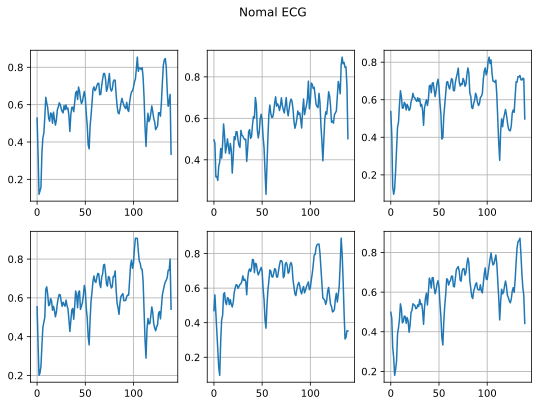

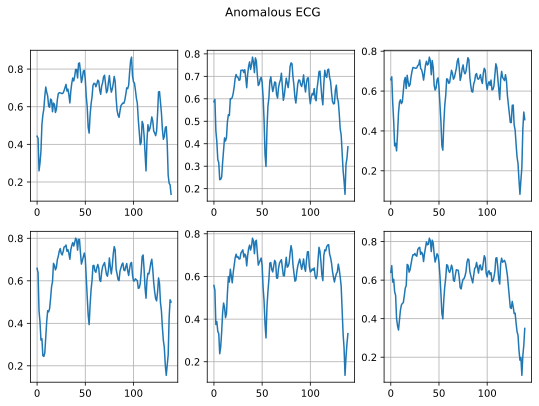

In [11]:
# 정상 비정상 시각화
normal_x_train = x_train[y_train]
fig, axes = plt.subplots(ncols=3, nrows=2, figsize=(9,6))
fig.suptitle("Nomal ECG")
axes = axes.ravel()
for idx, ax in enumerate(axes):
    ax.grid()
    ax.plot(np.arange(len(normal_x_train[idx])), normal_x_train[idx])
plt.show()

anormalous_x_train = x_train[~y_train]
fig, axes = plt.subplots(ncols=3, nrows=2, figsize=(9,6))
fig.suptitle("Anomalous ECG")
axes = axes.ravel()
for idx, ax in enumerate(axes):
    ax.grid()
    ax.plot(np.arange(len(anormalous_x_train[idx])),anormalous_x_train[idx])
plt.show()

In [12]:
# 입력데이터 차원 변경
x_train_ex = tf.expand_dims(x_train, axis=2)
x_test_ex = tf.expand_dims(x_test, axis=2)

print(x_train_ex.shape) # 심박수 특징 하나니 1추가

(3998, 140, 1)


In [13]:
model = tf.keras.Sequential([
    layers.LSTM(100, return_sequences=True, input_shape=(x_train_ex.shape[1], x_train_ex.shape[2])),
    layers.Dropout(0.25),
    layers.Bidirectional(layers.LSTM(100)),
    layers.Dropout(0.25),
    layers.Dense(1, activation='sigmoid')
])

In [14]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 140, 100)          40800     
                                                                 
 dropout (Dropout)           (None, 140, 100)          0         
                                                                 
 bidirectional (Bidirection  (None, 200)               160800    
 al)                                                             
                                                                 
 dropout_1 (Dropout)         (None, 200)               0         
                                                                 
 dense (Dense)               (None, 1)                 201       
                                                                 
Total params: 201801 (788.29 KB)
Trainable params: 201801 (788.29 KB)
Non-trainable params: 0 (0.00 Byte)
________________

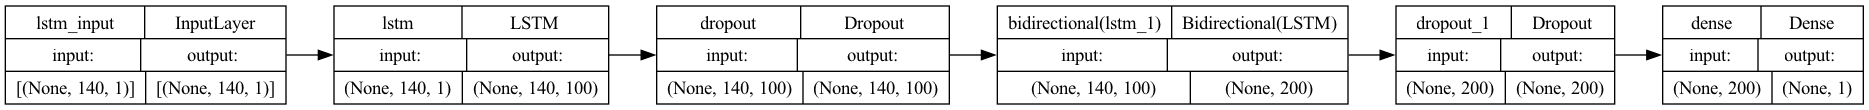

In [15]:
tf.keras.utils.plot_model(model, show_shapes=True, rankdir="LR")

In [16]:
model.compile(loss = 'binary_crossentropy',
              optimizer = tf.keras.optimizers.Adam(learning_rate=0.001))

- 지도학습때는 컴파일 함수 안에 loss를 넣음

In [17]:
training_record = model.fit(x_train_ex, y_train,
                            epochs=30,
                            batch_size=128,
                            validation_data=(x_train_ex, y_train),
                            shuffle=True)

Epoch 1/30


2026-03-15 22:20:50.943024: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2026-03-15 22:20:51.178423: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


32/32 [==============================] - 9s 154ms/step - loss: 0.4310 - val_loss: 0.0910
Epoch 2/30
32/32 [==============================] - 3s 98ms/step - loss: 0.0976 - val_loss: 0.0789
Epoch 3/30
32/32 [==============================] - 3s 85ms/step - loss: 0.0705 - val_loss: 0.0589
Epoch 4/30
32/32 [==============================] - 3s 85ms/step - loss: 0.0563 - val_loss: 0.0520
Epoch 5/30
32/32 [==============================] - 3s 93ms/step - loss: 0.0548 - val_loss: 0.0438
Epoch 6/30
32/32 [==============================] - 3s 90ms/step - loss: 0.0488 - val_loss: 0.0393
Epoch 7/30
32/32 [==============================] - 3s 87ms/step - loss: 0.0419 - val_loss: 0.0407
Epoch 8/30
32/32 [==============================] - 3s 87ms/step - loss: 0.0521 - val_loss: 0.0424
Epoch 9/30
32/32 [==============================] - 3s 87ms/step - loss: 0.0401 - val_loss: 0.0421
Epoch 10/30
32/32 [==============================] - 3s 84ms/step - loss: 0.0464 - val_loss: 0.0372
Epoch 11/30
32/32 [

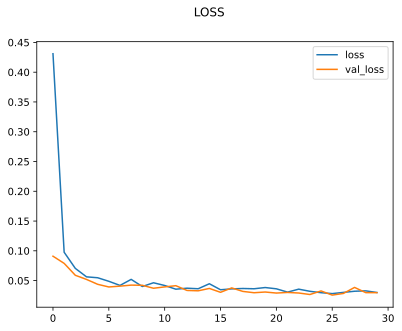

In [18]:
fig, ax = plt.subplots()
plt.plot(training_record.history["loss"], label="loss")
plt.plot(training_record.history["val_loss"], label="val_loss")
plt.legend()
plt.suptitle("LOSS")
plt.show()

In [19]:
# 평가
pred_proba = model.predict(x_test_ex)

32/32 [==============================] - 2s 23ms/step


In [23]:
pred_proba_1d = pred_proba.reshape(-1)

threshold = 0.5
pred = (pred_proba_1d >= threshold)

In [24]:
# 성능 계산하기
accuracy_test = accuracy_score(y_test, pred)
precision_test = precision_score(y_test, pred)
recall_test = recall_score(y_test, pred)

In [26]:
print(accuracy_test)
print(round(precision_test, 3))
print(recall_test)

0.99
0.988
0.9948630136986302
